# Predictive Analytics — Responsiveness & Support Speed

## Analytical Statement
**Customers who enjoy service interactions are more likely to return.**

## Dataset Category
**Category 1: Responsiveness & Support Speed**

## Main Objective
Build and evaluate machine learning models to predict `retention_label` using service interaction variables such as:

- `csat_score`
- `response_minutes`
- `channel_name`
- `category`
- `sub_category`
- `tenure_bucket`
- `agent_shift`

The final goal is to check whether service interaction-related variables can predict customer retention/return behavior.

# 1. Environment Setup

This section installs and imports the required Python libraries.

`imbalanced-learn` is used for SMOTE because the target class is imbalanced.

In [1]:
!pip -q install imbalanced-learn

In [2]:
# =========================
# Core libraries
# =========================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Scikit-learn tools
# =========================
from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# =========================
# Imbalanced learning tools
# =========================
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 2. Load the Dataset

Upload `dimension_01_dataset.csv` to Colab before running this section.

If the file is already available in the Colab working directory, the code will load it directly.

In [3]:
DATA_PATH = "dimension_01_dataset.csv"

try:
    df_raw = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    from google.colab import files
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
    df_raw = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df_raw.shape)

df_raw.head()

Dataset loaded successfully.
Shape: (2894, 9)


,channel_name,category,sub_category,customer_remarks,tenure_bucket,agent_shift,csat_score,response_minutes,retention_label
0,Outcall,Product Queries,Life Insurance,NaN,On Job Training,Morning,5,34.0,1.0
1,Outcall,Product Queries,Product Specific Information,NaN,>90,Morning,5,2.0,1.0
2,Inbound,Order Related,Installation/demo,NaN,On Job Training,Evening,5,22.0,1.0
3,Inbound,Returns,Reverse Pickup Enquiry,NaN,>90,Evening,5,20.0,1.0
4,Inbound,Cancellation,Not Needed,NaN,0-30,Morning,5,2.0,1.0


# 3. Initial Dataset Understanding

This section checks:

- column names
- data types
- missing values
- duplicate rows
- target class distribution

This is important before modelling because missing values, duplicates, and class imbalance can affect model performance.

In [4]:
print("Column names:")
print(df_raw.columns.tolist())

print("\n" + "--" * 50)
print("Dataset information:")
print(df_raw.info())

print("\n" + "--" * 50)
print("Missing values:")
display(df_raw.isna().sum().to_frame("missing_count"))

print("\n" + "--" * 50)
print("Duplicate rows:")
print(df_raw.duplicated().sum())

print("\n" + "--" * 50)
print("Target distribution:")
display(df_raw["retention_label"].value_counts(dropna=False).to_frame("count"))

print("\nTarget distribution percentage:")
display((df_raw["retention_label"].value_counts(normalize=True, dropna=False) * 100).to_frame("percentage"))

Column names:
['channel_name', 'category', 'sub_category', 'customer_remarks', 'tenure_bucket', 'agent_shift', 'csat_score', 'response_minutes', 'retention_label']

----------------------------------------------------------------------------------------------------
Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2894 entries, 0 to 2893
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   channel_name      2894 non-null   object 
 1   category          2894 non-null   object 
 2   sub_category      2894 non-null   object 
 3   customer_remarks  979 non-null    object 
 4   tenure_bucket     2894 non-null   object 
 5   agent_shift       2894 non-null   object 
 6   csat_score        2894 non-null   int64  
 7   response_minutes  2846 non-null   float64
 8   retention_label   2737 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 203.6+ KB
None

--------------------

,missing_count
channel_name,0
category,0
sub_category,0
customer_remarks,1915
tenure_bucket,0
agent_shift,0
csat_score,0
response_minutes,48
retention_label,157



----------------------------------------------------------------------------------------------------
Duplicate rows:
246

----------------------------------------------------------------------------------------------------
Target distribution:


,count
retention_label,
1.0,2299
0.0,438
NaN,157



Target distribution percentage:


,percentage
retention_label,
1.0,79.440221
0.0,15.134762
NaN,5.425017


## Initial Output Interpretation

From the original notebook output:

- The raw dataset has **2,894 rows** and **9 columns**.
- `customer_remarks` has many missing values, so it is removed from structured modelling.
- `response_minutes` has a small number of missing values, so median imputation is suitable.
- `retention_label` has missing values; those rows are removed because supervised learning requires a known target.
- The target is imbalanced because most records belong to class `1` / retained.

# 4. Project Configuration

All column names and modelling settings are stored in one place.

This makes the notebook easier to maintain.

In [6]:
RANDOM_STATE = 42

TARGET = "retention_label"

DROP_TEXT_COLUMNS = ["customer_remarks"]

NUMERIC_FEATURES = [
    "csat_score",
    "response_minutes"
]

TENURE_FEATURE = ["tenure_bucket"]

TENURE_ORDER = [
    "On Job Training",
    "0-30",
    "31-60",
    "61-90",
    ">90"
]

NOMINAL_FEATURES = [
    "channel_name",
    "category",
    "sub_category",
    "agent_shift"
]

REQUIRED_COLUMNS = (
    NUMERIC_FEATURES
    + TENURE_FEATURE
    + NOMINAL_FEATURES
    + DROP_TEXT_COLUMNS
    + [TARGET]
)

# Keep False unless you are sure repeated rows are data-entry mistakes.
# In customer service datasets, repeated-looking rows can still represent different interactions.
DROP_DUPLICATES = False

# Keep False for the main model because the model should learn feature importance naturally.
APPLY_FEATURE_WEIGHTS = False

FEATURE_WEIGHTS = {
    # "csat_score": 1.25,
    "response_minutes": 1.25
}

# 5. Basic Cleaning Before EDA and Modelling

Cleaning decisions:

1. Remove `customer_remarks` because it is mostly missing and text-based.
2. Remove rows with missing `retention_label`.
3. Convert `retention_label` into integer type.
4. Convert numeric columns into proper numeric format.
5. Strip extra spaces from categorical columns.
6. Validate ordered tenure values.

In [7]:
df = df_raw.copy()
df.columns = df.columns.str.strip()

missing_required = [col for col in REQUIRED_COLUMNS if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Remove text remarks column from structured model
df = df.drop(columns=DROP_TEXT_COLUMNS, errors="ignore")

# Optional duplicate removal
if DROP_DUPLICATES:
    before_rows = df.shape[0]
    df = df.drop_duplicates()
    after_rows = df.shape[0]
    print(f"Dropped duplicate rows: {before_rows - after_rows}")

# Rows without target cannot be used for supervised learning
df = df.dropna(subset=[TARGET]).copy()
df[TARGET] = df[TARGET].astype(int)

# Convert numeric features
for col in NUMERIC_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Clean categorical features
for col in NOMINAL_FEATURES + TENURE_FEATURE:
    df[col] = df[col].astype("string").str.strip()

# Validate tenure values
unexpected_tenure = sorted(set(df["tenure_bucket"].dropna()) - set(TENURE_ORDER))
if unexpected_tenure:
    raise ValueError(f"Unexpected tenure_bucket values found: {unexpected_tenure}")

print("Cleaned dataset shape:", df.shape)

print("\nTarget distribution after cleaning:")
display(df[TARGET].value_counts().to_frame("count"))

print("\nTarget percentage after cleaning:")
display((df[TARGET].value_counts(normalize=True) * 100).to_frame("percentage"))

df.head()

Cleaned dataset shape: (2737, 8)

Target distribution after cleaning:


,count
retention_label,
1,2299
0,438



Target percentage after cleaning:


,percentage
retention_label,
1,83.997077
0,16.002923


,channel_name,category,sub_category,tenure_bucket,agent_shift,csat_score,response_minutes,retention_label
0,Outcall,Product Queries,Life Insurance,On Job Training,Morning,5,34.0,1
1,Outcall,Product Queries,Product Specific Information,>90,Morning,5,2.0,1
2,Inbound,Order Related,Installation/demo,On Job Training,Evening,5,22.0,1
3,Inbound,Returns,Reverse Pickup Enquiry,>90,Evening,5,20.0,1
4,Inbound,Cancellation,Not Needed,0-30,Morning,5,2.0,1


## Cleaned Data Output Interpretation

From the original notebook output:

- After removing rows with missing `retention_label`, the dataset contains **2,737 rows** and **8 columns**.
- Class `1` contains **2,299 records**.
- Class `0` contains **438 records**.
- The minority class is around **16%**, so this is an imbalanced binary classification problem.

Because of this imbalance, accuracy alone is not enough. A model predicting only the majority class can still get high accuracy.

# 6. Exploratory Data Analysis (EDA)

EDA is used to understand the dataset before training models.

## 6.1 Target Class Distribution

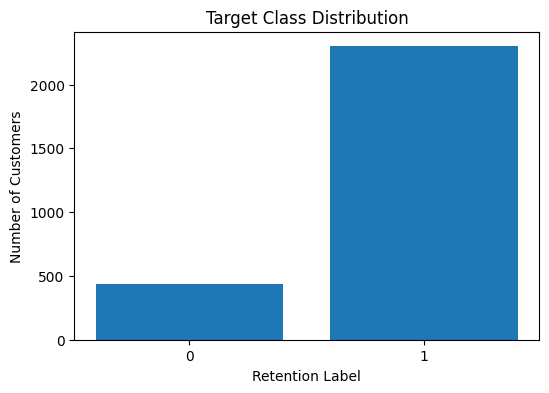

,count
retention_label,
0,438
1,2299


In [8]:
target_counts = df[TARGET].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Target Class Distribution")
plt.xlabel("Retention Label")
plt.ylabel("Number of Customers")
plt.show()

display(target_counts.to_frame("count"))

## 6.2 CSAT Score Distribution

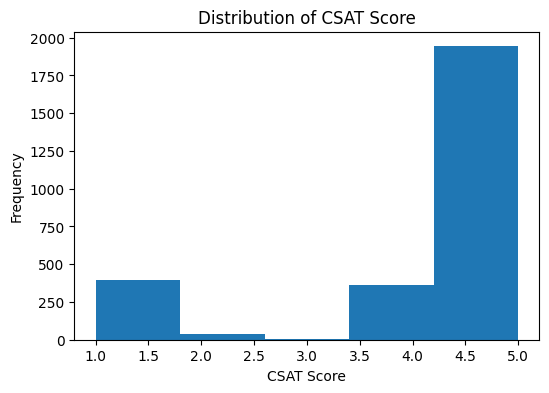

,count
csat_score,
1,393
2,37
3,3
4,362
5,1942


In [9]:
plt.figure(figsize=(6, 4))
plt.hist(df["csat_score"].dropna(), bins=5)
plt.title("Distribution of CSAT Score")
plt.xlabel("CSAT Score")
plt.ylabel("Frequency")
plt.show()

display(df["csat_score"].value_counts().sort_index().to_frame("count"))

## 6.3 Response Time Distribution

`response_minutes` is expected to be skewed because some support interactions can take much longer than others.

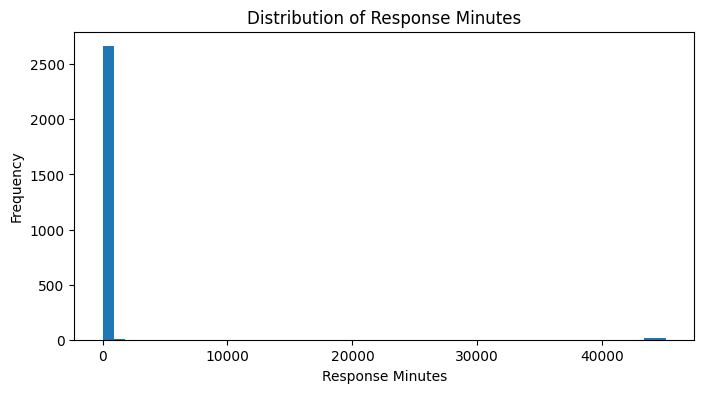

,response_minutes
count,2698.000000
mean,576.641586
std,4860.604324
min,0.000000
25%,2.000000
50%,5.000000
75%,19.000000
90%,112.300000
95%,245.150000
99%,43813.240000


In [10]:
plt.figure(figsize=(8, 4))
plt.hist(df["response_minutes"].dropna(), bins=50)
plt.title("Distribution of Response Minutes")
plt.xlabel("Response Minutes")
plt.ylabel("Frequency")
plt.show()

display(df["response_minutes"].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame("response_minutes"))

## 6.4 CSAT Score by Retention Label

<Figure size 600x400 with 0 Axes>

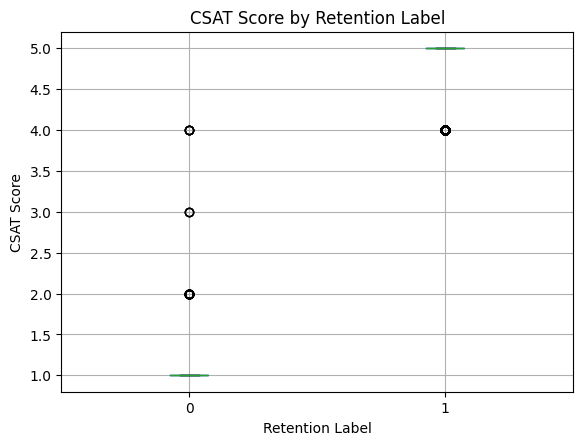

,count,mean,std,min,25%,50%,75%,max
retention_label,,,,,,,,
0,438.0,1.132420,0.444441,1.0,1.0,1.0,1.0,4.0
1,2299.0,4.844715,0.362255,4.0,5.0,5.0,5.0,5.0


In [11]:
plt.figure(figsize=(6, 4))
df.boxplot(column="csat_score", by=TARGET)
plt.title("CSAT Score by Retention Label")
plt.suptitle("")
plt.xlabel("Retention Label")
plt.ylabel("CSAT Score")
plt.show()

display(df.groupby(TARGET)["csat_score"].describe())

## 6.5 Response Minutes by Retention Label

<Figure size 600x400 with 0 Axes>

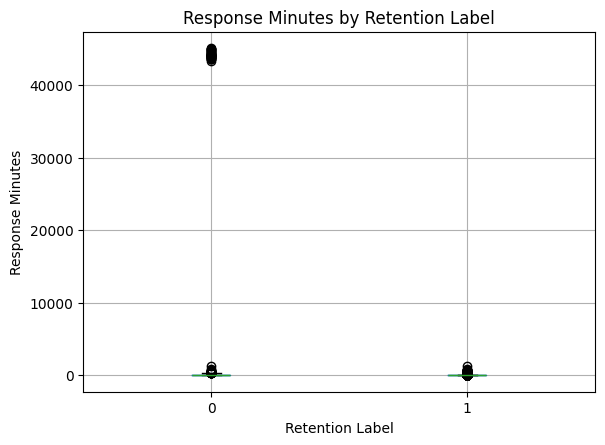

,count,mean,std,min,25%,50%,75%,max
retention_label,,,,,,,,
0,420.0,3538.797619,11900.165044,0.0,4.0,16.0,114.25,45127.0
1,2278.0,30.502195,86.352017,0.0,2.0,4.0,14.00,1337.0


In [12]:
plt.figure(figsize=(6, 4))
df.boxplot(column="response_minutes", by=TARGET)
plt.title("Response Minutes by Retention Label")
plt.suptitle("")
plt.xlabel("Retention Label")
plt.ylabel("Response Minutes")
plt.show()

display(df.groupby(TARGET)["response_minutes"].describe())

## 6.6 Correlation Heatmap

Categorical columns must be encoded before correlation analysis.

For EDA only:

- `tenure_bucket` is ordinal encoded.
- nominal categorical columns are one-hot encoded.
- numeric missing values are filled using the median.

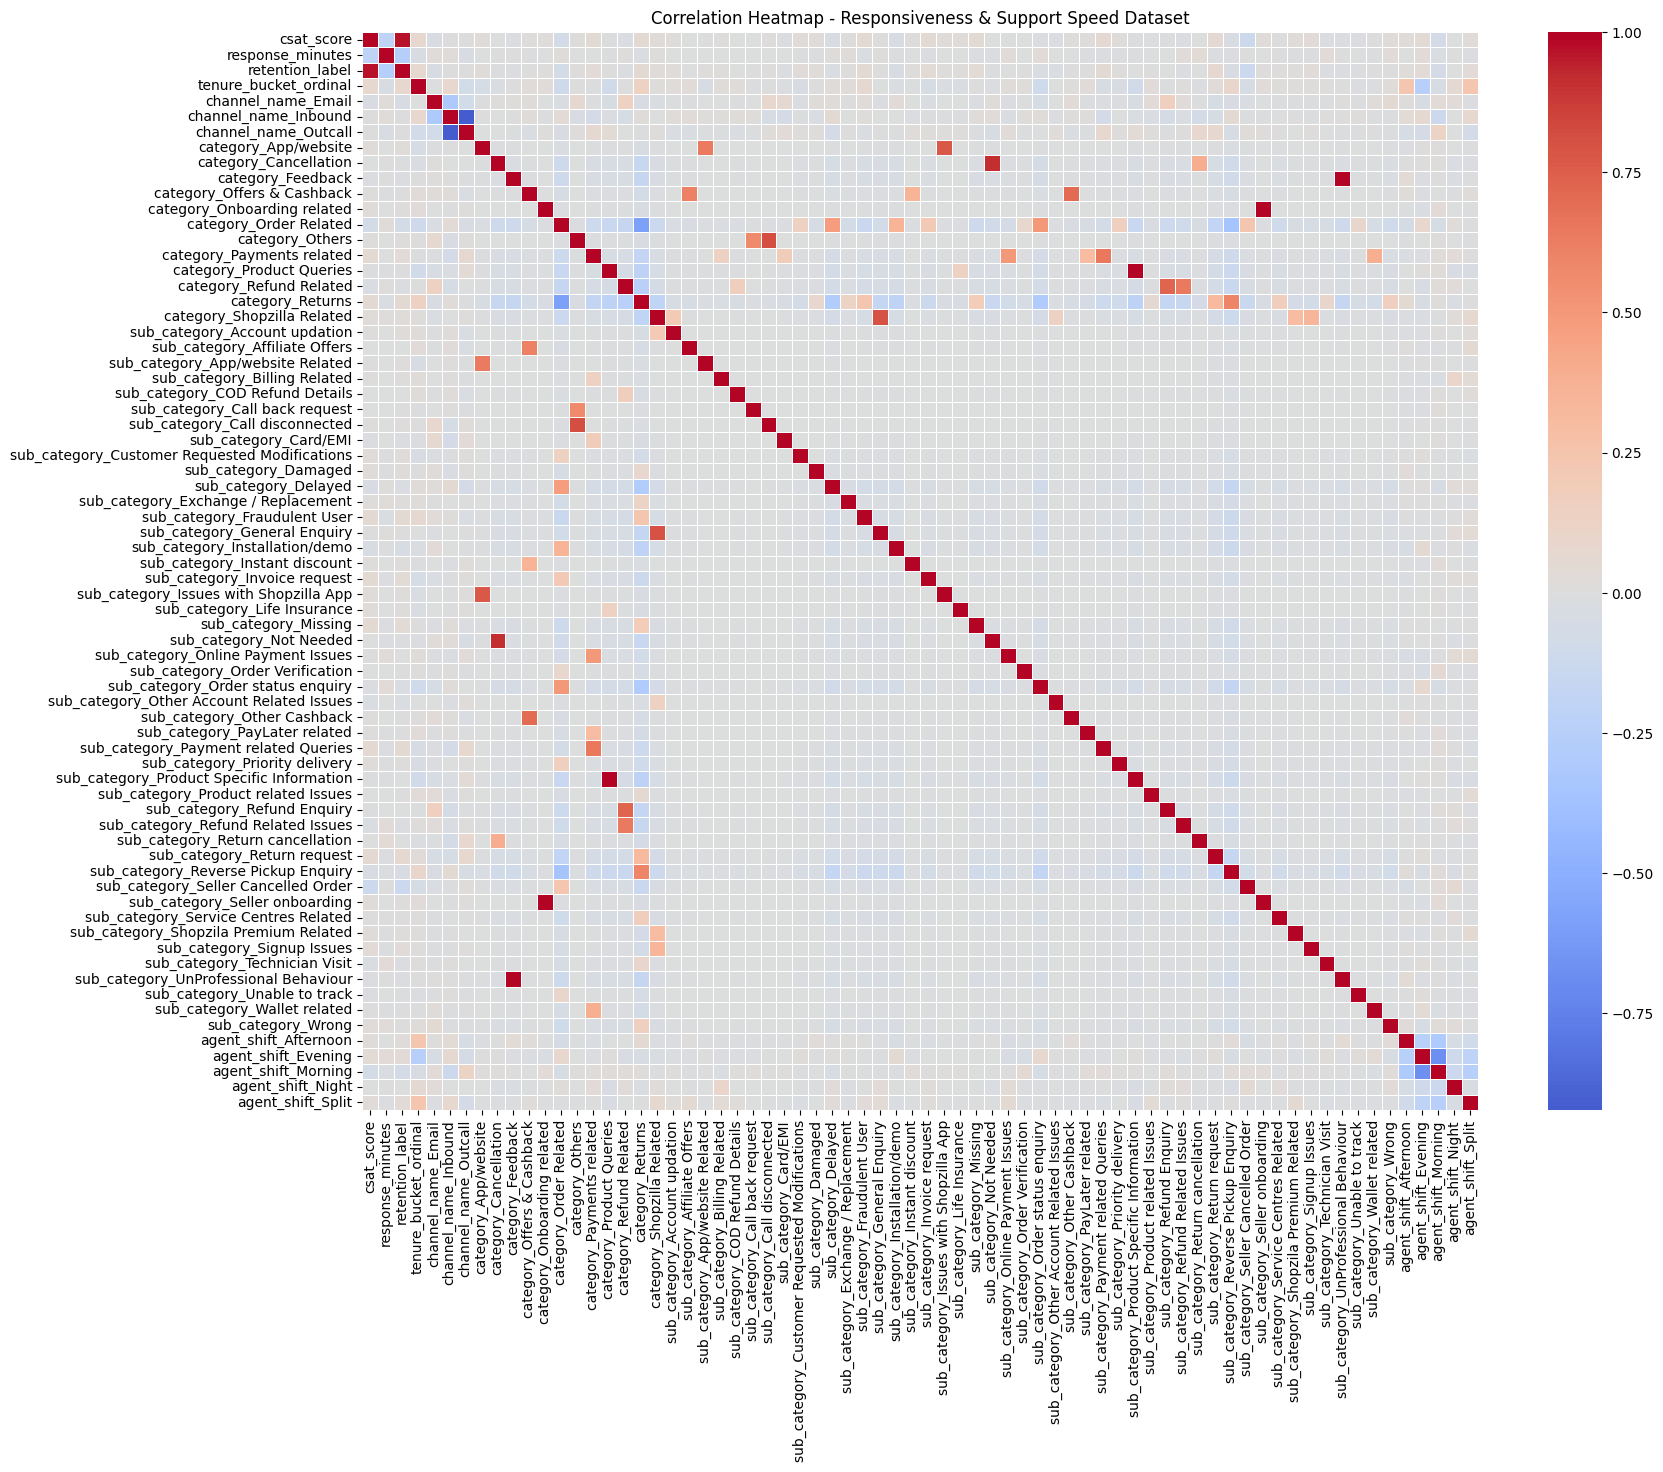

In [13]:
eda_df = df.copy()

# Fill numeric missing values for EDA correlation
for col in NUMERIC_FEATURES:
    eda_df[col] = eda_df[col].fillna(eda_df[col].median())

# Ordinal encode tenure
tenure_mapping = {
    "On Job Training": 0,
    "0-30": 1,
    "31-60": 2,
    "61-90": 3,
    ">90": 4
}
eda_df["tenure_bucket_ordinal"] = eda_df["tenure_bucket"].map(tenure_mapping)

# One-hot encode nominal variables
eda_encoded = pd.get_dummies(
    eda_df,
    columns=NOMINAL_FEATURES,
    drop_first=False,
    dtype=int
)

eda_encoded = eda_encoded.drop(columns=["tenure_bucket"], errors="ignore")

numeric_corr_df = eda_encoded.select_dtypes(include=["number"])
corr_matrix = numeric_corr_df.corr(method="pearson")

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)
plt.title("Correlation Heatmap - Responsiveness & Support Speed Dataset")
plt.show()

## 6.7 Target-Focused Correlation Heatmap

The full heatmap can be too crowded, so this target-focused version is easier for the report.

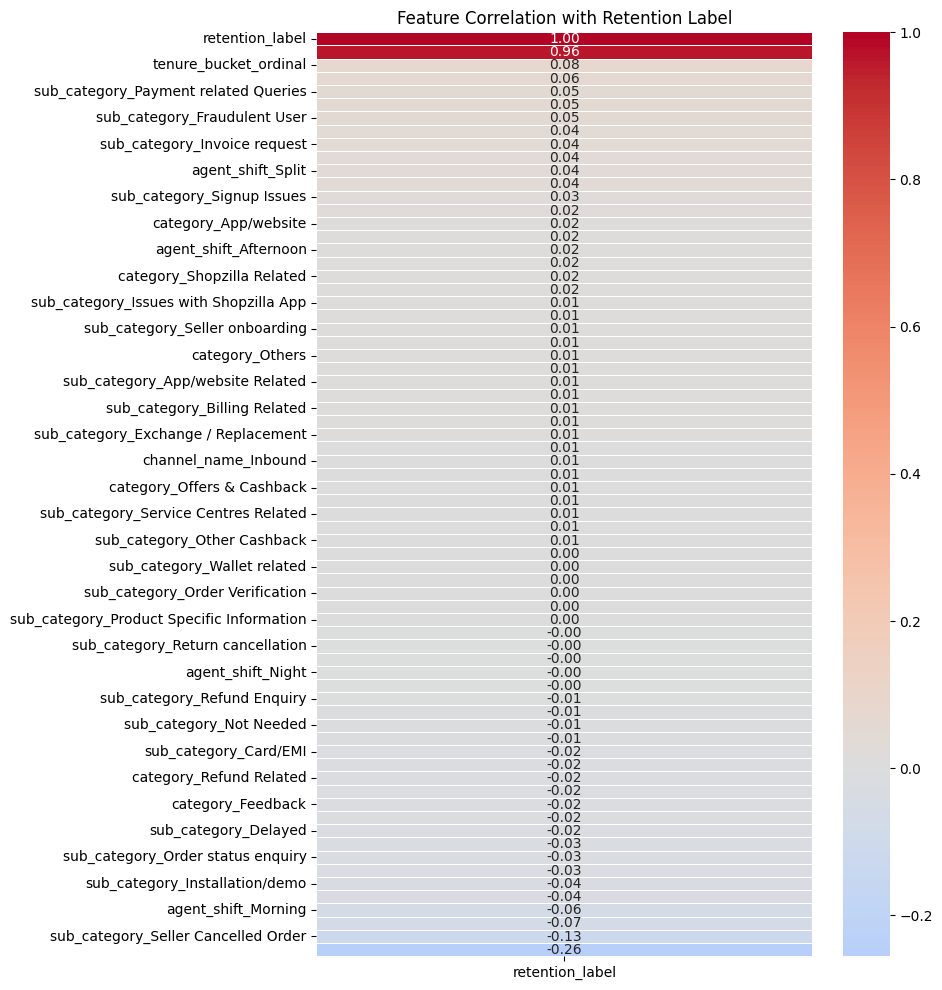

Top positive correlations with retention:


,retention_label
retention_label,1.000000
csat_score,0.963812
tenure_bucket_ordinal,0.075756
sub_category_Return request,0.064474
sub_category_Payment related Queries,0.053157
category_Returns,0.052016
sub_category_Fraudulent User,0.048908
sub_category_Missing,0.044129
sub_category_Invoice request,0.043133
category_Payments related,0.037171


Top negative correlations with retention:


,retention_label
sub_category_Delayed,-0.024114
sub_category_Other Account Related Issues,-0.025075
sub_category_Order status enquiry,-0.025387
sub_category_Reverse Pickup Enquiry,-0.029228
sub_category_Installation/demo,-0.036366
channel_name_Email,-0.036612
agent_shift_Morning,-0.062326
category_Order Related,-0.068828
sub_category_Seller Cancelled Order,-0.127343
response_minutes,-0.255542


In [14]:
target_corr = corr_matrix[[TARGET]].sort_values(
    by=TARGET,
    ascending=False
)

plt.figure(figsize=(8, 12))
sns.heatmap(
    target_corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Feature Correlation with Retention Label")
plt.show()

print("Top positive correlations with retention:")
display(target_corr.head(10))

print("Top negative correlations with retention:")
display(target_corr.tail(10))

## EDA Conclusion

Based on the original notebook output:

- The dataset is imbalanced, with class `1` being the majority class.
- `csat_score` has a very strong positive relationship with `retention_label`.
- `response_minutes` has a negative relationship with `retention_label`, meaning longer response times are linked with lower retention.
- Some categorical variables have weak relationships, but they are much less important than `csat_score` and `response_minutes`.

Important warning: if `retention_label` was created using `csat_score` or response-time rules, then the very strong model performance may indicate label leakage.

# 7. Prepare Features and Target

`X` contains the input variables.

`y` contains the target variable: `retention_label`.

In [15]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

minority_percentage = y.value_counts(normalize=True).min()
USE_SMOTE = minority_percentage < 0.35

print("Minority class percentage:", round(minority_percentage * 100, 2), "%")
print("Use SMOTE:", USE_SMOTE)

Feature shape: (2737, 7)
Target shape: (2737,)
Minority class percentage: 16.0 %
Use SMOTE: True


# 8. Train-Test Split

A stratified split is used so that both training and testing sets keep similar class ratios.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTrain target distribution:")
display((y_train.value_counts(normalize=True) * 100).to_frame("percentage"))

print("\nTest target distribution:")
display((y_test.value_counts(normalize=True) * 100).to_frame("percentage"))

Training set: (2189, 7)
Testing set: (548, 7)

Train target distribution:


,percentage
retention_label,
1,84.010964
0,15.989036



Test target distribution:


,percentage
retention_label,
1,83.941606
0,16.058394


# 9. Build the Preprocessing Pipeline

Different feature types need different preprocessing:

## Numeric features
- Median imputation
- Standard scaling

## Ordered categorical feature
- Mode imputation
- Ordinal encoding
- Standard scaling

## Nominal categorical features
- Mode imputation
- One-hot encoding

The pipeline keeps preprocessing inside the training workflow and reduces data leakage risk.

In [17]:
set_config(transform_output="pandas")

numeric_transformer = SkPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

tenure_transformer = SkPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[TENURE_ORDER],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        ),
        ("scaler", StandardScaler())
    ]
)

nominal_transformer = SkPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("tenure", tenure_transformer, TENURE_FEATURE),
        ("cat", nominal_transformer, NOMINAL_FEATURES)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# 10. Optional Feature Weighting

This is kept only for experimentation.

For the main final result, keep `APPLY_FEATURE_WEIGHTS = False` because the model should learn feature importance naturally.

In [18]:
class FeatureWeightTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, weights=None):
        self.weights = weights or {}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        for col_name, weight in self.weights.items():
            if col_name in X.columns:
                X[col_name] = X[col_name] * weight

        return X

# 11. Pipeline Builder Function

This function creates a full model pipeline:

Raw data → preprocessing → optional feature weighting → optional SMOTE → model

In [19]:
def make_pipeline(model, use_smote=False, apply_feature_weights=False):
    steps = [
        ("preprocess", preprocessor)
    ]

    if apply_feature_weights:
        steps.append(("feature_weights", FeatureWeightTransformer(FEATURE_WEIGHTS)))

    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)))

    steps.append(("model", model))

    return ImbPipeline(steps=steps)

# 12. Model Evaluation Function

The evaluation uses:

- Accuracy
- Balanced accuracy
- Precision
- Recall
- F1-score
- Macro F1-score
- ROC-AUC
- Confusion matrix
- ROC curve

Because the dataset is imbalanced, `balanced_accuracy` and `f1_macro` are more useful than accuracy alone.

In [20]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test, show_report=True):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    results = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_return_1": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall_return_1": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_return_1": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    if show_report:
        print("=" * 80)
        print(name)
        print("=" * 80)

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, zero_division=0))

        cm = confusion_matrix(y_test, y_pred)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Not Returned / Not Retained", "Returned / Retained"]
        )
        disp.plot()
        plt.title(f"Confusion Matrix - {name}")
        plt.show()

        if y_proba is not None:
            RocCurveDisplay.from_predictions(y_test, y_proba)
            plt.title(f"ROC Curve - {name}")
            plt.show()

    return results, model

# 13. Define Baseline and Machine Learning Models

Baselines are important because they show what performance can be achieved without real learning.

Models tested:

1. Most frequent class baseline
2. Stratified random baseline
3. Logistic Regression
4. Class-weighted Logistic Regression
5. Random Forest
6. Class-weighted Random Forest
7. SMOTE versions, if imbalance exists

In [21]:
models = {
    "Baseline: Most Frequent Class": make_pipeline(
        DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
        apply_feature_weights=APPLY_FEATURE_WEIGHTS
    ),

    "Baseline: Stratified Random": make_pipeline(
        DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
        apply_feature_weights=APPLY_FEATURE_WEIGHTS
    ),

    "Logistic Regression": make_pipeline(
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        apply_feature_weights=APPLY_FEATURE_WEIGHTS
    ),

    "Logistic Regression - Class Weighted": make_pipeline(
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        apply_feature_weights=APPLY_FEATURE_WEIGHTS
    ),

    "Random Forest": make_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        apply_feature_weights=APPLY_FEATURE_WEIGHTS
    ),

    "Random Forest - Class Weighted": make_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        apply_feature_weights=APPLY_FEATURE_WEIGHTS
    )
}

if USE_SMOTE:
    models["Logistic Regression + SMOTE"] = make_pipeline(
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        use_smote=True,
        apply_feature_weights=APPLY_FEATURE_WEIGHTS
    )

    models["Random Forest + SMOTE"] = make_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        use_smote=True,
        apply_feature_weights=APPLY_FEATURE_WEIGHTS
    )

print("Models prepared:")
for model_name in models.keys():
    print("-", model_name)

Models prepared:
- Baseline: Most Frequent Class
- Baseline: Stratified Random
- Logistic Regression
- Logistic Regression - Class Weighted
- Random Forest
- Random Forest - Class Weighted
- Logistic Regression + SMOTE
- Random Forest + SMOTE


# 14. Train and Compare Initial Models

In [22]:
all_results = []
trained_models = {}

for name, model in models.items():
    result, fitted_model = evaluate_model(
        name,
        model,
        X_train,
        X_test,
        y_train,
        y_test,
        show_report=False
    )

    all_results.append(result)
    trained_models[name] = fitted_model

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    by=["f1_macro", "balanced_accuracy", "roc_auc"],
    ascending=False
)

display(results_df)

,model,accuracy,balanced_accuracy,precision_return_1,recall_return_1,f1_return_1,f1_macro,roc_auc
2,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,Logistic Regression - Class Weighted,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,Random Forest - Class Weighted,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,Logistic Regression + SMOTE,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,Random Forest + SMOTE,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,Baseline: Stratified Random,0.697080,0.461166,0.826667,0.808696,0.817582,0.462555,0.461166
0,Baseline: Most Frequent Class,0.839416,0.500000,0.839416,1.000000,0.912698,0.456349,0.500000


## Initial Model Comparison Plots

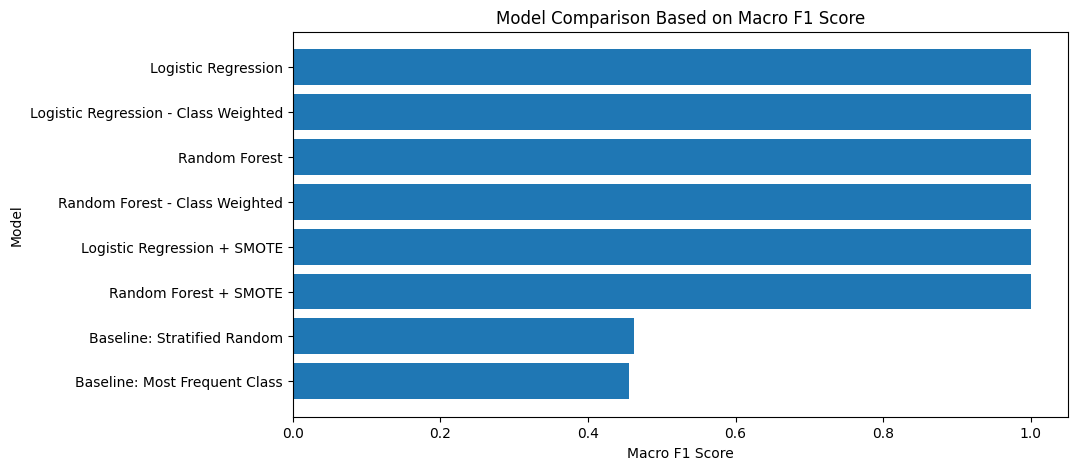

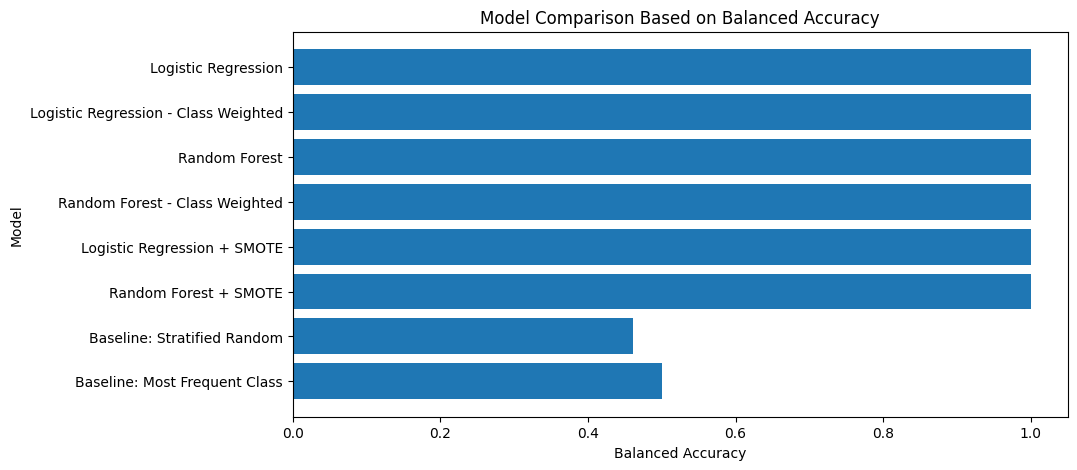

In [23]:
plt.figure(figsize=(10, 5))
plt.barh(results_df["model"], results_df["f1_macro"])
plt.xlabel("Macro F1 Score")
plt.ylabel("Model")
plt.title("Model Comparison Based on Macro F1 Score")
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(10, 5))
plt.barh(results_df["model"], results_df["balanced_accuracy"])
plt.xlabel("Balanced Accuracy")
plt.ylabel("Model")
plt.title("Model Comparison Based on Balanced Accuracy")
plt.gca().invert_yaxis()
plt.show()

## Initial Model Output Interpretation

From the original notebook output:

- The most frequent baseline achieved high accuracy because the dataset is imbalanced.
- However, its balanced accuracy was only **0.50**, meaning it failed to identify both classes properly.
- Logistic Regression, Random Forest, class-weighted models, and SMOTE models achieved perfect scores in the notebook output.
- This means the features separate the two retention classes almost completely.

This supports the analytical statement, but the perfect score should be explained carefully because it may also mean the target label is strongly based on `csat_score`.

# 15. Evaluate the Best Initial Model

Best initial model: Logistic Regression
Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        88
           1       1.00      1.00      1.00       460

    accuracy                           1.00       548
   macro avg       1.00      1.00      1.00       548
weighted avg       1.00      1.00      1.00       548



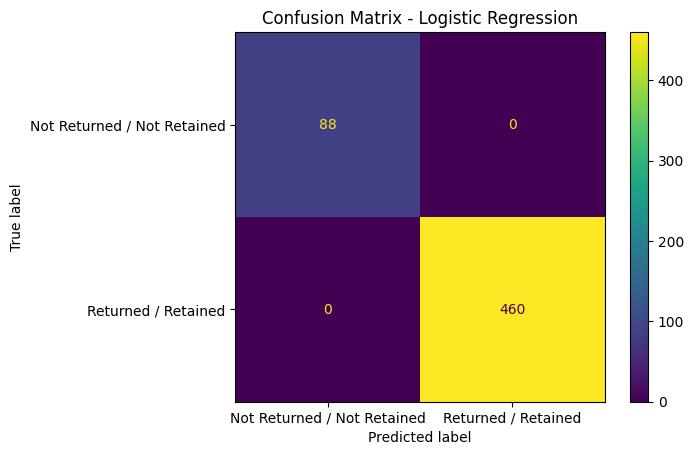

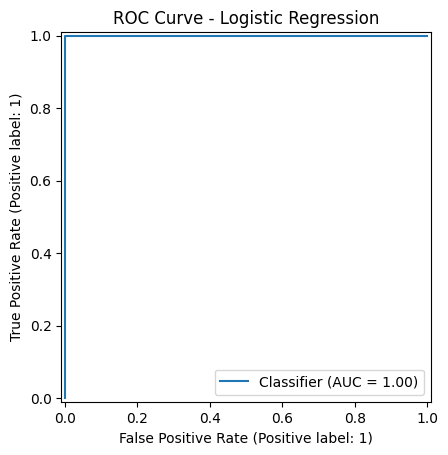

In [24]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best initial model:", best_model_name)

best_result, best_model = evaluate_model(
    best_model_name,
    best_model,
    X_train,
    X_test,
    y_train,
    y_test,
    show_report=True
)

# 16. Hyperparameter Tuning

GridSearchCV is used to test different parameter combinations using stratified cross-validation.

The model is selected based on `f1_macro` because the dataset is imbalanced.

In [25]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc"
}

tuning_candidates = {}

logistic_pipeline = make_pipeline(
    LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    use_smote=USE_SMOTE,
    apply_feature_weights=APPLY_FEATURE_WEIGHTS
)

logistic_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

if USE_SMOTE:
    logistic_grid["smote__k_neighbors"] = [3, 5]

tuning_candidates["Tuned Logistic Regression"] = (logistic_pipeline, logistic_grid)


# rf_pipeline = make_pipeline(
#     RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
#     use_smote=USE_SMOTE,
#     apply_feature_weights=APPLY_FEATURE_WEIGHTS
# )

# rf_grid = {
#     "model__n_estimators": [200, 300, 500],
#     "model__max_depth": [None, 5, 10, 20],
#     "model__min_samples_split": [2, 5, 10],
#     "model__min_samples_leaf": [1, 2, 4]
# }

# if USE_SMOTE:
#     rf_grid["smote__k_neighbors"] = [3, 5]

# tuning_candidates["Tuned Random Forest"] = (rf_pipeline, rf_grid)

# print("Hyperparameter tuning candidates prepared.")

In [26]:
tuned_results = []
tuned_models = {}
best_params = {}

for name, (pipeline, param_grid) in tuning_candidates.items():
    print("=" * 80)
    print("Tuning:", name)
    print("=" * 80)

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    print("Best parameters:")
    print(grid_search.best_params_)

    print("Best CV Macro F1:")
    print(grid_search.best_score_)

    best_tuned_model = grid_search.best_estimator_

    result, fitted_model = evaluate_model(
        name,
        best_tuned_model,
        X_train,
        X_test,
        y_train,
        y_test,
        show_report=False
    )

    tuned_results.append(result)
    tuned_models[name] = fitted_model
    best_params[name] = grid_search.best_params_

Tuning: Tuned Logistic Regression
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters:
{'model__C': 0.01, 'model__solver': 'liblinear', 'smote__k_neighbors': 3}
Best CV Macro F1:
1.0


# 17. Final Model Comparison

In [27]:
tuned_results_df = pd.DataFrame(tuned_results)

final_comparison_df = pd.concat(
    [results_df, tuned_results_df],
    ignore_index=True
)

final_comparison_df = final_comparison_df.sort_values(
    by=["f1_macro", "balanced_accuracy", "roc_auc"],
    ascending=False
)

display(final_comparison_df)

,model,accuracy,balanced_accuracy,precision_return_1,recall_return_1,f1_return_1,f1_macro,roc_auc
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,Logistic Regression - Class Weighted,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,Random Forest - Class Weighted,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,Logistic Regression + SMOTE,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,Random Forest + SMOTE,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,Tuned Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,Baseline: Stratified Random,0.697080,0.461166,0.826667,0.808696,0.817582,0.462555,0.461166
7,Baseline: Most Frequent Class,0.839416,0.500000,0.839416,1.000000,0.912698,0.456349,0.500000


## Hyperparameter Tuning Output Interpretation

From the original notebook output:

- Tuned Logistic Regression achieved **1.00 macro F1**.
- Tuned Random Forest achieved around **0.9966 macro F1** and **0.9982 accuracy**.
- Since Logistic Regression is simpler and achieved perfect performance, it is the best final model for this dataset.

This is useful for viva because a simpler model is easier to explain than a complex model when both perform equally well.

# 18. Final Best Model Evaluation

Final best model: Logistic Regression
Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        88
           1       1.00      1.00      1.00       460

    accuracy                           1.00       548
   macro avg       1.00      1.00      1.00       548
weighted avg       1.00      1.00      1.00       548



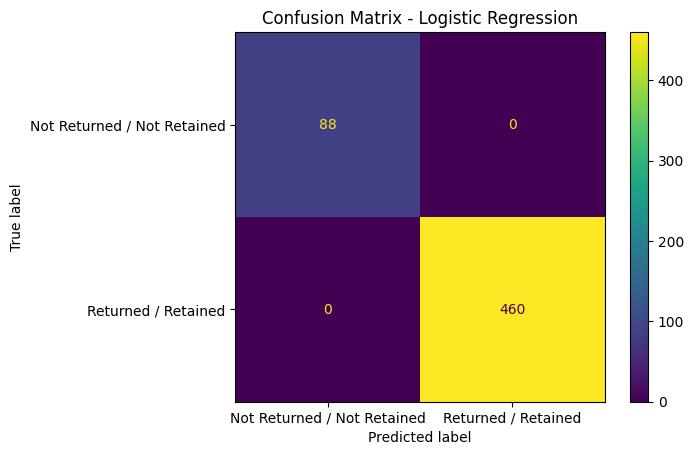

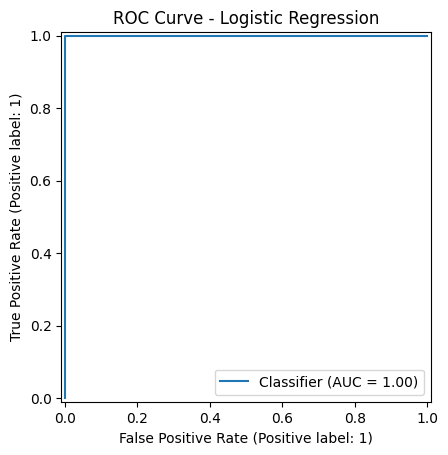

In [28]:
final_best_model_name = final_comparison_df.iloc[0]["model"]

if final_best_model_name in tuned_models:
    final_best_model = tuned_models[final_best_model_name]
else:
    final_best_model = trained_models[final_best_model_name]

print("Final best model:", final_best_model_name)

final_result, final_best_model = evaluate_model(
    final_best_model_name,
    final_best_model,
    X_train,
    X_test,
    y_train,
    y_test,
    show_report=True
)

# 19. Feature Importance

Feature importance is used to understand which variables contributed most to customer retention prediction.

## 19.1 Permutation Importance on Original Features

Permutation importance shows how much model performance drops when each original feature is shuffled.

,feature,importance_mean,importance_std
5,csat_score,0.500665,0.023987
6,response_minutes,0.013320,0.002348
0,channel_name,0.000000,0.000000
2,sub_category,0.000000,0.000000
1,category,0.000000,0.000000
4,agent_shift,0.000000,0.000000
3,tenure_bucket,0.000000,0.000000


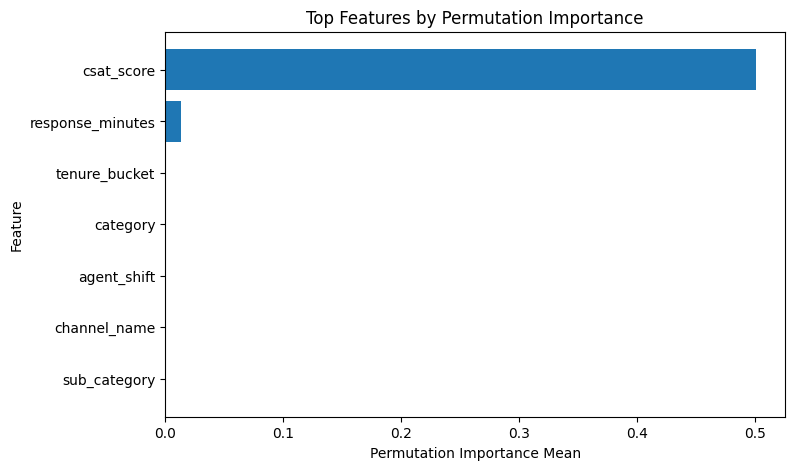

In [29]:
perm_result = permutation_importance(
    final_best_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

perm_importance_df = perm_importance_df.sort_values(
    by="importance_mean",
    ascending=False
)

display(perm_importance_df)

top_perm = perm_importance_df.head(10).sort_values("importance_mean")

plt.figure(figsize=(8, 5))
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.xlabel("Permutation Importance Mean")
plt.ylabel("Feature")
plt.title("Top Features by Permutation Importance")
plt.show()

## 19.2 Model-Based Feature Importance

For Logistic Regression, this shows the most influential coefficients after preprocessing.

For Random Forest, this shows built-in feature importance.

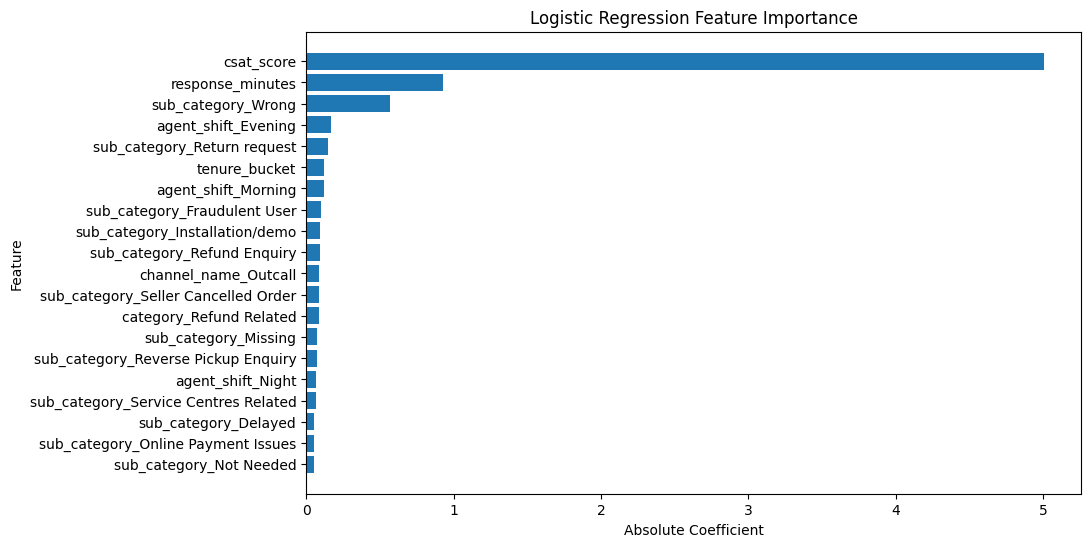

,feature,coefficient,absolute_coefficient
0,csat_score,5.008718,5.008718
1,response_minutes,-0.930096,0.930096
63,sub_category_Wrong,-0.569751,0.569751
65,agent_shift_Evening,0.168989,0.168989
52,sub_category_Return request,0.151424,0.151424
2,tenure_bucket,0.121438,0.121438
66,agent_shift_Morning,-0.117932,0.117932
30,sub_category_Fraudulent User,0.102634,0.102634
32,sub_category_Installation/demo,0.095461,0.095461
49,sub_category_Refund Enquiry,0.091468,0.091468


In [30]:
def get_transformed_feature_names(fitted_pipeline):
    return fitted_pipeline.named_steps["preprocess"].get_feature_names_out()


def plot_model_based_importance(fitted_pipeline, top_n=20):
    model = fitted_pipeline.named_steps["model"]
    feature_names = get_transformed_feature_names(fitted_pipeline)

    if hasattr(model, "feature_importances_"):
        importance_values = model.feature_importances_

        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importance_values
        }).sort_values("importance", ascending=False)

        top_df = importance_df.head(top_n).sort_values("importance")

        plt.figure(figsize=(10, 6))
        plt.barh(top_df["feature"], top_df["importance"])
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.title("Model-Based Feature Importance")
        plt.show()

        return importance_df

    elif hasattr(model, "coef_"):
        coef_values = model.coef_[0]

        importance_df = pd.DataFrame({
            "feature": feature_names,
            "coefficient": coef_values,
            "absolute_coefficient": np.abs(coef_values)
        }).sort_values("absolute_coefficient", ascending=False)

        top_df = importance_df.head(top_n).sort_values("absolute_coefficient")

        plt.figure(figsize=(10, 6))
        plt.barh(top_df["feature"], top_df["absolute_coefficient"])
        plt.xlabel("Absolute Coefficient")
        plt.ylabel("Feature")
        plt.title("Logistic Regression Feature Importance")
        plt.show()

        return importance_df

    else:
        print("This model does not provide direct feature importance or coefficients.")
        return None


model_importance_df = plot_model_based_importance(final_best_model, top_n=20)

if model_importance_df is not None:
    display(model_importance_df.head(20))

## Feature Importance Output Interpretation

From the original notebook output:

- `csat_score` was the strongest feature by far.
- `response_minutes` had a smaller but still meaningful effect.
- Other features such as `channel_name`, `category`, `sub_category`, `agent_shift`, and `tenure_bucket` had near-zero permutation importance.

This means customer satisfaction score and response time are the main predictive variables for retention in this dataset.

# 20. Save Results

In [ ]:
final_comparison_df.to_csv("dataset_01_model_comparison_results.csv", index=False)
perm_importance_df.to_csv("dataset_01_permutation_importance.csv", index=False)

if model_importance_df is not None:
    model_importance_df.to_csv("dataset_01_model_based_importance.csv", index=False)

print("Saved:")
print("- dataset_01_model_comparison_results.csv")
print("- dataset_01_permutation_importance.csv")
if model_importance_df is not None:
    print("- dataset_01_model_based_importance.csv")

# 21. Final Predictive Analytics Conclusion

The best model in the original notebook was **Logistic Regression**, which achieved perfect performance on the test set.

This means the dataset features were able to predict customer retention very strongly.

## Main conclusion

The predictive analytics result supports the analytical statement:

> Customers who enjoy service interactions are more likely to return.

## Evidence from this dataset

- Higher `csat_score` strongly increased the chance of retention.
- Longer `response_minutes` reduced the chance of retention.
- Logistic Regression and Random Forest performed much better than baseline models.
- Feature importance confirmed that `csat_score` and `response_minutes` were the most important predictors.

## Important limitation

Because `csat_score` almost perfectly separates retained and non-retained customers, we must make sure that `retention_label` was not created directly from `csat_score`. If the label was derived from CSAT, then the model is mainly learning the label creation rule rather than discovering a real-world prediction pattern.